# 线性规划模型代码

线性规划（Linear Programming, LP）是在一组**线性**等式/不等式约束下，求**线性**目标函数最大值或最小值的问题，是数学建模竞赛中**最常用**的优化模型之一。

**写作流程**：1.概念说明；2.逐一用文字描述每个约束条件，并在段后或段前附上对应公式；3.符号说明；4.几何解释

通用形式（linprog 使用的标准形式）：

$$\min \ c^Tx \quad s.t. \ A_{ub}x \le b_{ub}, \ A_{eq}x = b_{eq}, \ l \le x \le u$$

本 Notebook 按顺序覆盖竞赛中最常用的线性规划模型：标准 LP（生产计划）、含等式约束（配比问题）、运输问题、指派问题、0-1 整数规划与二维图解法。每个方法的注释中都说明了输入、输出、优缺点和适用场景。

## 准备工作

先导入所有需要的库，后面不再重复导入。

In [9]:
# 导入线性规划所需的库。
import numpy as np
from scipy.optimize import linprog, milp, Bounds, LinearConstraint, linear_sum_assignment
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 设置中文显示和绘图参数。
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (8, 5)

print("所有库导入成功")

所有库导入成功


# 一、标准线性规划（linprog）

## 1. 资源分配问题（利润最大化）

某工厂生产两种产品 A、B，消耗三种资源，问如何安排产量使总利润最大。

- **输入**：目标系数 c、不等式约束 A_ub/b_ub、变量边界 bounds
- **输出**：res.x 最优解、-res.fun 最优值、res.message 求解状态
- **优点**：HiGHS 求解器成熟稳健，大规模问题也能快速求解
- **缺点**：只能处理线性目标与线性约束；默认求最小值，最大化必须把目标系数取负
- **适用场景**：生产计划、资源分配、线性利润/成本优化

典型约束特征：
- 总量约束
- 非负约束
- 需求/上限约束

In [2]:
# 资源分配问题：两种产品，三种资源约束，利润最大化。
# 模型：max z = 3*x1 + 2*x2
#       s.t.  2*x1 +   x2 <= 100   资源1
#              x1 +   x2 <=  80   资源2
#              x1         <=  40   资源3
#              x1, x2 >= 0

# c 为目标系数。linprog 只做最小化，因此把利润系数取负，最小化 -z 等价于最大化 z。
c = np.array([-3.0, -2.0])

# A_ub 为不等式约束系数矩阵，每行对应一条约束；b_ub 为对应右端项。
A_ub = np.array([[2.0, 1.0],
                 [1.0, 1.0],
                 [1.0, 0.0]])
b_ub = np.array([100.0, 80.0, 40.0])

# bounds 给出每个变量的下界和上界，(0, None) 表示 x >= 0 且无上界。
bounds = [(0, None), (0, None)]

# method='highs' 是默认且最稳健的求解器（HiGHS 内点法/单纯形法自动选择）。
res = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')

print("求解状态:", res.message)
print(f"最优解: x1 = {res.x[0]:.2f}, x2 = {res.x[1]:.2f}")
print(f"最大利润 z = {-res.fun:.2f}")

求解状态: Optimization terminated successfully. (HiGHS Status 7: Optimal)
最优解: x1 = 20.00, x2 = 60.00
最大利润 z = 180.00


## 2. 松弛量（Slack Variable）

松弛量是为把**不等式约束**变成等式而引入的非负变量。对每条约束 $a^Tx \le b$，定义松弛量：

$$s = b - a^Tx \ge 0, \qquad a^Tx + s = b$$

它表示该约束中**没用完的资源量**：

| 松弛量的值 | 含义 | 启示 |
|-----------|------|------|
| $s = 0$ | 资源刚好用完（约束绷紧） | 该约束是"瓶颈"，增加该资源能提升目标值 |
| $s > 0$ | 资源有剩余（约束不起作用） | 增加该资源对目标值没有帮助 |

在本例最优解 $x_1=20,\ x_2=60$ 处：资源1、2 刚好用完（松弛量 = 0），资源3 还剩 20 单位。

**注意**：等式约束（A_eq/b_eq）没有松弛量；linprog 会自动为每条 A_ub 约束引入松弛变量，无需手动添加。

- **输出**：`res.slack` 按 A_ub 的行顺序给出每条约束的松弛量
- **适用场景**：判断哪些约束真正限制方案、配合对偶价格做瓶颈资源分析


In [3]:
# 查看资源分配问题各约束的松弛量（需先运行上一单元格求解 res）。
# res.slack 按 A_ub 的行顺序返回每条不等式约束的松弛量。
slack = res.slack
constraint_names = ["资源1: 2x1 + x2 <= 100",
                    "资源2: x1  + x2 <= 80",
                    "资源3: x1      <= 40"]

print("各约束的松弛量（剩余资源）：")
for name, s in zip(constraint_names, slack):
    status = "资源刚好用完（瓶颈约束）" if s < 1e-8 else f"剩余 {s:.2f} 单位"
    print(f"  {name}: 松弛量 = {s:.2f}  ->  {status}")

各约束的松弛量（剩余资源）：
  资源1: 2x1 + x2 <= 100: 松弛量 = 0.00  ->  资源刚好用完（瓶颈约束）
  资源2: x1  + x2 <= 80: 松弛量 = 0.00  ->  资源刚好用完（瓶颈约束）
  资源3: x1      <= 40: 松弛量 = 20.00  ->  剩余 20.00 单位


# 二、含等式约束的线性规划（A_eq / b_eq）

## 1. 营养配比问题

当某些约束要求"恰好等于"（总量固定、资源恰好用完、产销平衡）时，用等式约束 A_eq/b_eq 表达。

- **输入**：成本系数 c、等式约束 A_eq/b_eq、不等式约束 A_ub/b_ub（>= 需取负转为 <=）
- **输出**：最优配比与最小成本
- **优点**：等式约束直接写入，与数学模型一一对应，表达自然
- **缺点**：>= 约束需要手动两边取负转成 <=，符号容易写反
- **适用场景**：原料配比混合、总量固定、资源恰好用完的平衡问题

In [4]:
# 营养配比问题：两种原料混合成 100 kg 饲料，满足蛋白质、脂肪最低需求，求最小成本。
# 原料1：成本 0.6 元/kg，蛋白质 30%，脂肪 10%
# 原料2：成本 0.8 元/kg，蛋白质 20%，脂肪 30%
#
# 模型：min z = 0.6*x1 + 0.8*x2
#       s.t.      x1 +   x2 = 100             总量恰好 100 kg（等式约束）
#            -0.3*x1 - 0.2*x2 <= -25   蛋白质 >= 25
#            -0.1*x1 - 0.3*x2 <= -20   脂肪   >= 20
#            x1, x2 >= 0

c = np.array([0.6, 0.8])

# >= 约束两边取负转成 <=：0.3*x1 + 0.2*x2 >= 25 等价于 -0.3*x1 - 0.2*x2 <= -25。
A_ub = np.array([[-0.3, -0.2],
                 [-0.1, -0.3]])
b_ub = np.array([-25.0, -20.0])

# 等式约束：A_eq 每行一个等式，x1 + x2 = 100。
A_eq = np.array([[1.0, 1.0]])
b_eq = np.array([100.0])
bounds = [(0, None), (0, None)]

res = linprog(c, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq,
              bounds=bounds, method='highs')

print("求解状态:", res.message)
print(f"最优配比: 原料1 = {res.x[0]:.2f} kg, 原料2 = {res.x[1]:.2f} kg")
print(f"最小成本 = {res.fun:.2f} 元")

求解状态: Optimization terminated successfully. (HiGHS Status 7: Optimal)
最优配比: 原料1 = 50.00 kg, 原料2 = 50.00 kg
最小成本 = 70.00 元


# 三、运输问题

## 1. 产销平衡运输模型

m 个产地（供应量 $a_i$）向 n 个销地（需求量 $b_j$）供货，求总运费最小的调运方案 $x_{ij}$：

$$\min \sum_{i=1}^{m}\sum_{j=1}^{n} c_{ij}x_{ij} \quad s.t. \ \sum_j x_{ij} = a_i, \ \sum_i x_{ij} = b_j, \ x_{ij} \ge 0$$

- **输入**：运费矩阵 cost、供应量 supply、需求量 demand
- **输出**：最优调运方案矩阵、最小总运费
- **优点**：模型结构规整、约束稀疏，linprog 秒解
- **缺点**：变量数 = 产地数 × 销地数，规模大时模型矩阵较宽
- **适用场景**：物流调度、电力分配、供应链规划

In [5]:
# 运输问题：3 个产地向 4 个销地供货，产销平衡，求最小总运费方案。

# 运费矩阵：行 = 产地，列 = 销地；供应量/需求量数组。
cost = np.array([[4, 6, 8, 7],
                 [6, 5, 9, 4],
                 [8, 7, 6, 5]])
# 注意：供应量总和必须等于需求量总和（产销平衡），否则无可行解。
supply = np.array([50, 60, 70])      # 3 个产地的供应量（总和 180）
demand = np.array([45, 50, 40, 45])  # 4 个销地的需求量（总和 180）
m, n = cost.shape

# 决策变量 x11..x34 共 12 个，按行展开成一维向量；目标系数就是运费矩阵展平。
c = cost.ravel()

# 构造等式约束：产地行和 = 供应量，销地列和 = 需求量。
A_eq, b_eq = [], []
for i in range(m):
    row = np.zeros(m * n)
    row[i*n:(i+1)*n] = 1   # 产地 i 运往所有销地的变量
    A_eq.append(row); b_eq.append(supply[i])
for j in range(n):
    row = np.zeros(m * n)
    row[j::n] = 1          # 所有产地中第 j 列的变量
    A_eq.append(row); b_eq.append(demand[j])

res = linprog(c, A_eq=np.array(A_eq), b_eq=np.array(b_eq),
              bounds=[(0, None)] * (m * n), method='highs')

# 把一维最优解还原成 (产地, 销地) 矩阵。
x_opt = res.x.reshape(m, n)
print("求解状态:", res.message)
print("最优调运方案（行=产地, 列=销地）:")
print(np.round(x_opt, 2))
print(f"最小总运费 = {res.fun:.2f}")

求解状态: Optimization terminated successfully. (HiGHS Status 7: Optimal)
最优调运方案（行=产地, 列=销地）:
[[45.  5.  0.  0.]
 [ 0. 45.  0. 15.]
 [ 0.  0. 40. 30.]]
最小总运费 = 885.00


# 四、指派问题（匈牙利算法）

## 1. 人员-任务指派

n 个人完成 n 项任务，每人只能做一项，每项任务只能由一人完成，求总用时最小的指派方案。

$$\min \sum_{i,j} c_{ij}x_{ij} \quad s.t. \ \sum_j x_{ij}=1, \ \sum_i x_{ij}=1, \ x_{ij}\in\{0,1\}$$

- **输入**：效率/成本矩阵 cost (n, n)
- **输出**：row_ind 工人索引、col_ind 对应任务索引、最小总用时
- **优点**：匈牙利算法复杂度 O(n³)，无需建模成 LP 即可直接求解
- **缺点**：要求效率矩阵为方阵（n 人 n 任务）；人员与任务数不等时需补虚拟项
- **适用场景**：任务指派、工作分配、设备选配、选址配对

In [6]:
# 指派问题：5 名工人完成 5 项任务，求总用时最小的指派方案。

# 效率矩阵：行 = 工人，列 = 任务，数值为完成用时。
cost_assign = np.array([[9, 2, 7, 8, 5],
                        [6, 4, 3, 7, 8],
                        [5, 8, 1, 8, 6],
                        [7, 6, 9, 4, 3],
                        [8, 5, 6, 5, 4]])

# linear_sum_assignment 直接返回最优配对：row_ind[i] 与 col_ind[i] 构成一对。
row_ind, col_ind = linear_sum_assignment(cost_assign)

total = cost_assign[row_ind, col_ind].sum()
print("指派方案（工人 -> 任务）:")
for r, cc in zip(row_ind, col_ind):
    print(f"  工人{r+1} -> 任务{cc+1}，用时 {cost_assign[r, cc]}")
print(f"最小总用时 = {total}")

指派方案（工人 -> 任务）:
  工人1 -> 任务2，用时 2
  工人2 -> 任务1，用时 6
  工人3 -> 任务3，用时 1
  工人4 -> 任务5，用时 3
  工人5 -> 任务4，用时 5
最小总用时 = 17


# 五、整数线性规划（milp）

## 1. 0-1 背包问题

当决策变量要求为整数（尤其是 0-1 变量）时，用 `scipy.optimize.milp` 求解混合整数线性规划。

$$\max \sum_i v_i x_i \quad s.t. \ \sum_i w_i x_i \le W, \ x_i \in \{0,1\}$$

- **输入**：价值 v、重量 w、背包容量 W
- **输出**：最优选择方案（0/1 向量）、最大总价值
- **优点**：milp 直接支持整数/0-1 变量，模型表达清晰；目标取负即可求最大
- **缺点**：整数规划是 NP-hard，规模大时求解时间指数增长
- **适用场景**：是否投资的 0-1 决策、选址问题、整数数量的生产决策

In [7]:
# 0-1 背包问题：从 10 件物品中选若干件，总重量不超过容量 W，使总价值最大。

v = np.array([12, 8, 15, 10, 20, 16, 25, 14, 18, 9])   # 各物品价值
w = np.array([6, 4, 7, 5, 8, 6, 9, 6, 8, 5])           # 各物品重量
W = 35                                                 # 背包容量
n = len(v)

# milp 默认求最小值，求最大值时目标系数取负：c = -v。
# constraints: LinearConstraint(系数, 下界, 上界)，重量约束为 w·x <= W。
# integrality=1 表示所有变量要求为整数；Bounds(0, 1) 限定 0-1 变量。
res = milp(c=-v,
           constraints=LinearConstraint(w, -np.inf, W),
           integrality=np.ones(n),
           bounds=Bounds(0, 1))

print("求解状态:", res.message)
selected = np.where(res.x > 0.5)[0]
print("选中的物品编号:", selected + 1)
print(f"总重量 = {w[selected].sum()}, 最大总价值 = {-res.fun:.0f}")

求解状态: Optimization terminated successfully. (HiGHS Status 7: Optimal)
选中的物品编号: [1 5 6 7 8]
总重量 = 35, 最大总价值 = 87


# 六、二维线性规划图解法

## 1. 可行域与等值线可视化

两个变量的线性规划可以画出可行域和目标函数等值线，直观验证最优解（最优解总在可行域的某个顶点处取得）。

- **输入**：各不等式约束的直线表达式、目标函数系数
- **输出**：可行域填充图 + 等值线 + 最优解标记
- **优点**：直观展示"约束交点是极值点"的几何意义，适合论文插图
- **缺点**：仅限二维；变量超过 2 个无法直接画图
- **适用场景**：教学演示、结果可视化、对最优解做几何验证

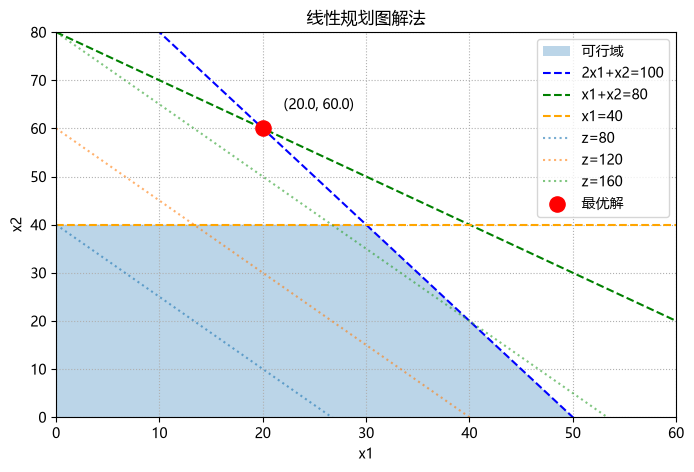

In [8]:
# 用第一节生产计划问题做图解法（本单元格自含求解，可独立运行）。

# 重新求解第一节的模型，得到最优解坐标。
c_plot = np.array([-3.0, -2.0])
A_plot = np.array([[2.0, 1.0], [1.0, 1.0], [1.0, 0.0]])
b_plot = np.array([100.0, 80.0, 40.0])
res_plot = linprog(c_plot, A_ub=A_plot, b_ub=b_plot,
                   bounds=[(0, None), (0, None)], method='highs')
opt = res_plot.x

x1 = np.linspace(0, 60, 400)
# 由各不等式解出 x2 的上界曲线：
line1 = 100 - 2 * x1    # 2x1 + x2 <= 100 -> x2 <= 100 - 2x1
line2 = 80 - x1         #  x1 + x2 <=  80 -> x2 <=  80 - x1

# 可行域：x2 同时 <= 三条上界（含 x2 <= 40），且 >= 0。
x2_feas = np.minimum(np.minimum(line1, line2), 40)
x2_feas = np.maximum(x2_feas, 0)

plt.figure(figsize=(8, 5))
plt.fill_between(x1, 0, x2_feas, where=(x2_feas >= 0), alpha=0.3, label='可行域')
plt.plot(x1, line1, 'b--', label='2x1+x2=100')
plt.plot(x1, line2, 'g--', label='x1+x2=80')
plt.axhline(40, color='orange', ls='--', label='x1=40')

# 目标等值线：z = 3x1 + 2x2，画几条平行线观察最优方向。
for z in [80, 120, 160]:
    plt.plot(x1, (z - 3 * x1) / 2, ':', alpha=0.6, label=f'z={z}')

# 标记最优解。
plt.scatter(opt[0], opt[1], color='red', s=120, zorder=5, label='最优解')
plt.annotate(f'({opt[0]:.1f}, {opt[1]:.1f})', opt,
             xytext=(opt[0] + 2, opt[1] + 4))

plt.xlim(0, 60); plt.ylim(0, 80)
plt.xlabel('x1'); plt.ylabel('x2'); plt.title('线性规划图解法')
plt.grid(ls=':'); plt.legend(); plt.show()

# 七、敏感性分析（Sensitivity Analysis）

线性规划求出最优解后，还需要回答"如果数据变了，最优解和最优值会怎么变"。敏感性分析研究**参数扰动**（目标系数、约束右端项）对最优解的影响，是论文中"结果分析"部分的重要内容。

| 分析对象 | 含义 | 如何得到 |
|---------|------|---------|
| 影子价格（对偶价格） | 某约束右端项增加 1 单位时目标值的改变量 | `res.ineqlin.marginals`（linprog） |
| 目标系数允许变化范围 | c 在哪个区间内变动，当前最优解仍是最优 | linprog 的灵敏度返回 |
| 右端项允许变化范围 | b 在哪个区间内变动，影子价格仍有效 | linprog 的灵敏度返回 |
| 参数扫描曲线 | 手动逐个改变某参数，重解模型观察变化趋势 | 循环重解 + 绘图 |

- **输入**：求解后的 OptimizeResult 对象，或参数扫描区间
- **输出**：影子价格、允许变化范围、目标值随参数变化曲线
- **优点**：揭示哪些参数最敏感（关键约束/关键系数），指导决策与资源调配
- **缺点**：默认 linprog 不返回完整灵敏度，需用 `HiGHS 灵敏度` 选项或手动扫描
- **适用场景**：论文"灵敏度分析"小节；确定瓶颈资源；评估数据不确定性对结论的影响


In [10]:
# 1. 影子价格（对偶价格）与灵敏度
# 仍用第一节的资源分配问题：max z = 3x1 + 2x2，三种资源约束。

c_s = np.array([-3.0, -2.0])
A_s = np.array([[2.0, 1.0],
                [1.0, 1.0],
                [1.0, 0.0]])
b_s = np.array([100.0, 80.0, 40.0])
bounds_s = [(0, None), (0, None)]

# 使用 HiGHS 求解器并开启灵敏度分析。
# res.ineqlin.marginals: 每条不等式约束的影子价格（对偶变量），
#   含义是右端项增加 1 时，最优目标值的改变量（注意目标已取负，需还原符号）。
# res.ineqlin.lower/upper: 右端项 b 的允许变化范围（该范围内影子价格仍有效）。
res_s = linprog(c_s, A_ub=A_s, b_ub=b_s, bounds=bounds_s,
                method='highs', integrality=None)

print("=== 影子价格（各约束右端项增加 1 单位带来的利润变化）===")
names = ["资源1: 2x1+x2<=100", "资源2: x1+x2<=80", "资源3: x1<=40"]
for i, nm in enumerate(names):
    # HiGHS 返回的 marginals 对应 min -z 的敏感度，取负还原为 max z 的敏感度。
    shadow = -res_s.ineqlin.marginals[i]
    print(f"  {nm}: 影子价格 = {shadow:.4f}")

print(f"\n最优解 x1={res_s.x[0]:.2f}, x2={res_s.x[1]:.2f}, 最大利润 = {-res_s.fun:.2f}")
print("影子价格 > 0 表示该资源是瓶颈，增加它可提高利润；= 0 表示该资源有剩余。")

=== 影子价格（各约束右端项增加 1 单位带来的利润变化）===
  资源1: 2x1+x2<=100: 影子价格 = 1.0000
  资源2: x1+x2<=80: 影子价格 = 1.0000
  资源3: x1<=40: 影子价格 = 0.0000

最优解 x1=20.00, x2=60.00, 最大利润 = 180.00
影子价格 > 0 表示该资源是瓶颈，增加它可提高利润；= 0 表示该资源有剩余。


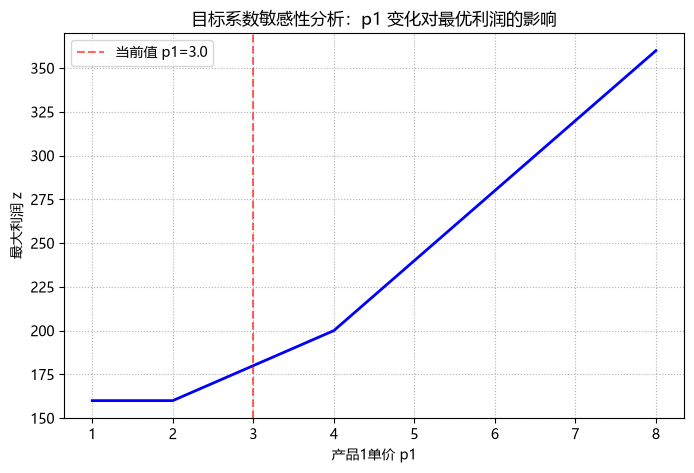

p1 = 1.0 -> z = 160.0
p1 = 3.0 -> z = 180.0
p1 = 5.0 -> z = 240.0
p1 = 8.0 -> z = 360.0


In [11]:
# 2. 参数扫描：目标系数变化对最优值的影响
# 当某系数在允许范围内变化时，最优解不变、最优值线性变化；超出范围后最优解跳变。
# 此方法无需额外库，任何问题都可做，是论文敏感性分析最常用的手段。

# 定义扫描函数：给定产品1单价 p1，重新求解资源分配问题，返回最优利润。
def solve_for_p1(p1):
    c_t = np.array([-p1, -2.0])            # 只改变 x1 的利润系数
    res_t = linprog(c_t, A_ub=A_s, b_ub=b_s,
                    bounds=bounds_s, method='highs')
    return -res_t.fun                       # 还原为最大化目标值

# 扫描 p1 从 1.0 到 8.0，观察最优利润的变化趋势。
p1_range = np.linspace(1.0, 8.0, 50)
profit_range = [solve_for_p1(p) for p in p1_range]

plt.figure(figsize=(8, 5))
plt.plot(p1_range, profit_range, 'b-', linewidth=2)
plt.axvline(3.0, color='r', ls='--', alpha=0.6, label='当前值 p1=3.0')
plt.xlabel('产品1单价 p1'); plt.ylabel('最大利润 z')
plt.title('目标系数敏感性分析：p1 变化对最优利润的影响')
plt.grid(ls=':'); plt.legend(); plt.show()

# 打印几个关键点的具体数值，供论文表格使用。
print("p1 = 1.0 -> z =", round(solve_for_p1(1.0), 2))
print("p1 = 3.0 -> z =", round(solve_for_p1(3.0), 2))
print("p1 = 5.0 -> z =", round(solve_for_p1(5.0), 2))
print("p1 = 8.0 -> z =", round(solve_for_p1(8.0), 2))

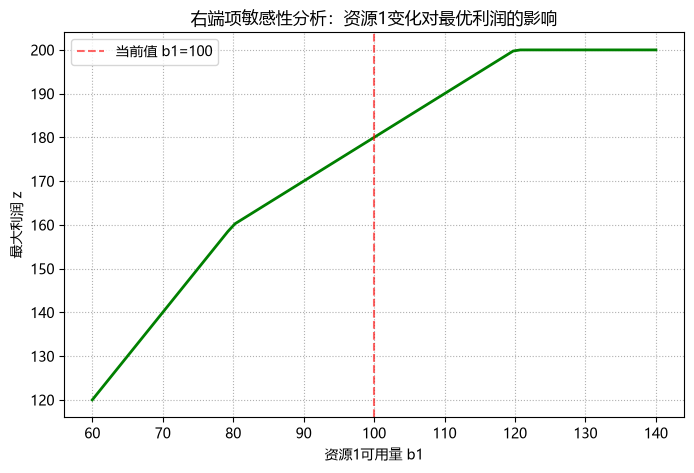

b1 = 80  -> z = 160.0
b1 = 100 -> z = 180.0
b1 = 120 -> z = 200.0
b1 = 140 -> z = 200.0


In [12]:
# 3. 右端项扫描：资源量变化对最优利润的影响
# 考察资源1从 60 增加到 140 时，最优利润如何变化（斜率即该资源的影子价格）。

# 定义扫描函数：给定资源1的可用量 b1，重新求解并返回最优利润。
def solve_for_b1(b1):
    b_t = np.array([b1, 80.0, 40.0])        # 只改变资源1的右端项
    res_t = linprog(c_s, A_ub=A_s, b_ub=b_t,
                    bounds=bounds_s, method='highs')
    return -res_t.fun

b1_range = np.linspace(60, 140, 80)
profit_b1 = [solve_for_b1(b) for b in b1_range]

plt.figure(figsize=(8, 5))
plt.plot(b1_range, profit_b1, 'g-', linewidth=2)
plt.axvline(100, color='r', ls='--', alpha=0.6, label='当前值 b1=100')
plt.xlabel('资源1可用量 b1'); plt.ylabel('最大利润 z')
plt.title('右端项敏感性分析：资源1变化对最优利润的影响')
plt.grid(ls=':'); plt.legend(); plt.show()

# 分段线性：斜率变化处即"瓶颈转移"点，该斜率正是影子价格。
print("b1 = 80  -> z =", round(solve_for_b1(80), 2))
print("b1 = 100 -> z =", round(solve_for_b1(100), 2))
print("b1 = 120 -> z =", round(solve_for_b1(120), 2))
print("b1 = 140 -> z =", round(solve_for_b1(140), 2))

# 总结：何时选用哪种方法

| 模型 | 求解函数 | 典型应用 | 关键注意点 |
|------|---------|---------|-----------|
| 标准线性规划 | `linprog` | 生产计划、资源分配 | 最大化需把 c 取负 |
| 含等式约束 LP | `linprog(A_eq, b_eq)` | 配比、产销平衡 | >= 约束取负转 <= |
| 运输问题 | `linprog` | 物流调度、供应链 | 变量展平 + 行和/列和约束 |
| 指派问题 | `linear_sum_assignment` | 任务分配 | 矩阵须为方阵 |
| 整数/0-1 规划 | `milp` | 背包、选址、投资 | 目标取负 + integrality + Bounds |

**建模通用流程**：
1. 明确决策变量 x 并编号，确定每个变量的含义和取值范围；
2. 写出目标函数（最大化转最小化时系数取负）；
3. 把所有约束写成 $Ax \le b$、$Ax = b$、$l \le x \le u$ 三种标准形式；
4. 先用 `linprog` 求解并检查 `res.status` 是否为 0（成功）；
5. 需要整数/0-1 变量时改用 `milp`；需要多目标或非线性时再考虑其他方法。